# 07 — GNN con attenzione (Transformer) per Anomaly Detection
### Emerging Jets vs QCD

In questo notebook usiamo una **Graph Neural Network** per riconoscere jet anomali, lavorando
direttamente sulle **tracce singole** del jet invece che su un riassunto compatto.

**Cos'è una GNN, intuitivamente.**
Molti dati non sono una semplice tabella di numeri, ma un **insieme di oggetti che si
relazionano** tra loro — un *grafo*. Qui ogni jet è un insieme di tracce: pensiamo a ogni
traccia come a un **nodo**, e immaginiamo dei collegamenti tra le tracce dello stesso jet. Una
GNN elabora questi nodi facendoli **«parlare» tra loro**: ogni traccia aggiorna la propria
rappresentazione guardando le altre tracce del jet. Così ogni traccia non è più vista da sola,
ma **nel contesto** del jet a cui appartiene.

**Perché serve una rappresentazione diversa.**
Gli altri modelli (AE, VAE, NF, diffusion) ricevevano il jet già *riassunto* in 43 numeri:
comodo e compatto, ma quel riassunto **butta via la struttura** traccia-per-traccia. Una GNN,
al contrario, vuole proprio quella struttura: l'insieme delle tracce con le loro 14 feature
ciascuna. È un input «ricco» — ed è il tipo di dato per cui le GNN sono fatte.

**Come la usiamo per l'anomaly detection.**
Costruiamo un **autoencoder sul grafo**: la rete comprime e poi ricostruisce le feature di ogni
traccia, sfruttando il contesto del jet. La alleniamo **solo su QCD**; lo score di anomalia è
**quanto male ricostruisce le tracce** di un jet:

$$\text{anomaly score} = \text{errore medio di ricostruzione delle tracce del jet} \quad (\text{più alto} = \text{più anomalo})$$

**Una premessa onesta.** Dare la struttura ricca *non garantisce* di vincere: dipende da quanto
l'informazione utile sta nelle *relazioni* tra tracce piuttosto che nelle statistiche aggregate.
Su questi dati gli EJ si distinguono in modo **diffuso su molte tracce**, quindi è normale
aspettarsi un risultato onesto ma non necessariamente superiore ai modelli tabellari.

> **Premessa — un approccio diverso dalla GNN classica (EdgeConv).** Nel notebook EdgeConv
> (`06_gnn_edgeconv`) le tracce comunicavano **a vicinato locale fisso**: un **grafo sparso kNN**,
> message passing **senza attenzione**, con gli archi decisi dalla geometria (η-φ). Qui usiamo
> l'approccio opposto: **connessione totale con pesi appresi** — ogni traccia è collegata a
> *tutte* le altre del jet, e l'**attenzione** decide quanto ciascuna conta. Tecnicamente è un
> **Graph Attention Network su grafo completo** (ogni traccia = un nodo, collegato a tutti gli
> altri, pesi = attenzione) — il che coincide con un **Transformer encoder** per insiemi non
> ordinati. È quindi la versione "tutti-con-tutti" della GNN classica.


---
## 1. Setup e iperparametri

> **In breve.** Carichiamo gli strumenti e fissiamo le impostazioni. Tratteremo ogni jet come
> un insieme di tracce (al massimo `TMAX`, quelle a pT più alto). Le manopole del modello sono
> la larghezza dell'embedding dei nodi, quanti strati di «dialogo» tra tracce (attenzione) e la
> dimensione del collo di bottiglia.


In [1]:
# ── Librerie ──────────────────────────────────────────────────────────────────
import os, sys, math, gc, warnings
warnings.filterwarnings('ignore')
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

PROJECT_DIR = r'C:\Users\dfraj\OneDrive\Desktop\Master\Adv_ML\Progetto\ej_anomaly'
sys.path.insert(0, PROJECT_DIR)
from Utils_NEW import load_tracks, clean_tracks, zscore_normalise, compute_roc, plot_roc

BKG_FILE = r'C:\Users\dfraj\Downloads\pp_output_test_background.h5'
SIG_FILE = r'C:\Users\dfraj\Downloads\pp_output_test_signal.h5'
MODELS_DIR = os.path.join(PROJECT_DIR, 'models')
PLOTS_DIR  = os.path.join(PROJECT_DIR, 'plots')
os.makedirs(MODELS_DIR, exist_ok=True); os.makedirs(PLOTS_DIR, exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)
print(f'Device: {DEVICE}')

# ── Iperparametri ─────────────────────────────────────────────────────────────
# La rappresentazione traccia-per-traccia occupa molta piu' memoria dell'aggregate:
# se vai in errore di memoria, abbassa N_BKG_TRAIN / N_SIG_EVAL oppure TMAX.
N_BKG_TRAIN = 50_000     # jet QCD usati
N_SIG_EVAL  = 50_000     # jet segnale usati nella valutazione (cap per memoria)
TMAX        = 64         # max tracce per jet (le piu' energetiche); il resto e' padding

# Modello (graph autoencoder con attenzione)
EMBED_DIM   = 64         # larghezza dell'embedding di ogni traccia (nodo)
N_ENC       = 2          # numero di layer di attenzione (quanto "dialogano" le tracce)
LATENT      = 8          # collo di bottiglia per traccia (la "latent dimension")
N_HEADS     = 4          # teste di attenzione
DROPOUT     = 0.0        # regolarizzazione

# Ottimizzazione
LEARNING_RATE = 1e-3
WEIGHT_DECAY  = 1e-5
BATCH_SIZE    = 256
N_EPOCHS      = 150
PATIENCE      = 25

TRAIN_FRAC, VAL_FRAC, TEST_FRAC = 0.70, 0.15, 0.15
SAVE_PATH = os.path.join(MODELS_DIR, f'gnn_locale_d{EMBED_DIM}_L{N_ENC}.pt')
print(f'Setup OK -> Graph AE: embed {EMBED_DIM}, {N_ENC} layer di attenzione, bottleneck {LATENT}')


Device: cpu
Setup OK -> Graph AE: embed 64, 2 layer di attenzione, bottleneck 8


---
## 2. Dai jet ai grafi di tracce

> **In breve.** Per ogni jet teniamo le sue tracce (al massimo `TMAX`, quelle a pT più alto),
> ciascuna con le sue 14 feature già normalizzate. Niente riassunto in 43 numeri: qui serve
> proprio la lista delle tracce, perché è su quella che la GNN lavora.

Passi:
1. **`load_tracks` + `clean_tracks`** — tracce grezze ripulite + maschera del padding.
2. **`zscore_normalise`** — normalizza ogni feature (z-score) con clip a 10σ. Dopo questo le
   feature di traccia sono già a media 0 e scala 1, quindi **non serve** una standardizzazione
   ulteriore (a differenza dell'embedding aggregate degli altri modelli).
3. **Selezione delle tracce** — ogni jet ha un numero variabile di tracce; ne teniamo al più
   `TMAX`, scegliendo le **più energetiche** (pT più alto). Otteniamo così un formato regolare
   `(jet, TMAX, 14)` più una maschera che dice quali nodi sono tracce vere e quali padding.


In [2]:
def prep_tracks(path, n_max, Tmax=TMAX):
    '''Carica i jet e li mette in forma (N, Tmax, 14) + maschera, tenendo le tracce a pT piu alto.'''
    tr = load_tracks(path, n_max=n_max)
    m  = tr['valid'].astype(bool)
    Xc, m = clean_tracks(tr, m)
    Xn = zscore_normalise(Xc, m)              # (N, 200, 14) gia' z-scored per traccia
    del Xc, tr; gc.collect()
    # ordina le tracce per pT (feature 0 = pt_log1p) e tieni le prime Tmax
    pt = np.where(m, Xn[:, :, 0], -1e9)
    order = np.argsort(-pt, axis=1)
    Xs = np.take_along_axis(Xn, order[:, :, None], axis=1)[:, :Tmax].astype(np.float32)
    ms = np.take_along_axis(m, order, axis=1)[:, :Tmax]
    del Xn, m, pt, order; gc.collect()
    return Xs, ms

print('Caricamento background (QCD)...')
X_bkg, M_bkg = prep_tracks(BKG_FILE, N_BKG_TRAIN)
print('Caricamento segnale (Emerging Jets)...')
X_sig, M_sig = prep_tracks(SIG_FILE, N_SIG_EVAL)
F = X_bkg.shape[2]
print(f'X_bkg: {X_bkg.shape}  X_sig: {X_sig.shape}  (tracce valide medie: {M_bkg.sum(1).mean():.1f})')


Caricamento background (QCD)...
Caricamento segnale (Emerging Jets)...
X_bkg: (50000, 64, 14)  X_sig: (50000, 64, 14)  (tracce valide medie: 52.7)


---
## 3. Split dei dati

> **In breve.** Dividiamo i jet QCD in allenamento / controllo / test (70/15/15). Il segnale
> resta da parte: lo tocchiamo solo alla fine, per la valutazione.


In [3]:
rng  = np.random.default_rng(SEED)
perm = rng.permutation(len(X_bkg))
n_tr = int(len(X_bkg) * TRAIN_FRAC)
n_vl = int(len(X_bkg) * VAL_FRAC)
idx_train, idx_val, idx_test = perm[:n_tr], perm[n_tr:n_tr+n_vl], perm[n_tr+n_vl:]

Xtr, Mtr = X_bkg[idx_train], M_bkg[idx_train]
Xvl, Mvl = X_bkg[idx_val],   M_bkg[idx_val]
Xte, Mte = X_bkg[idx_test],  M_bkg[idx_test]

train_loader = DataLoader(TensorDataset(torch.from_numpy(Xtr), torch.from_numpy(Mtr)),
                          batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
n_val = len(Xvl)
print(f'TRAIN {len(Xtr):,} | VAL {n_val:,} | TEST {len(Xte):,} | SIG {len(X_sig):,}')


TRAIN 35,000 | VAL 7,500 | TEST 7,500 | SIG 50,000


---
## 4. Il modello: graph autoencoder con attenzione

> **In breve.** Costruiamo un autoencoder che lavora sul grafo delle tracce. Il cuore è
> l'**attenzione**: ogni traccia guarda tutte le altre del jet e ne assorbe il contesto. Poi
> comprimiamo (collo di bottiglia) e ricostruiamo le 14 feature di ogni traccia. Se il modello,
> allenato sul QCD, ricostruisce male le tracce di un jet, quel jet è sospetto.

Come funziona, passo per passo:
1. **embedding** — ogni traccia (14 numeri) viene proiettata in un vettore più ampio;
2. **attenzione (il «dialogo» tra tracce)** — alcuni strati di self-attention fanno sì che ogni
   traccia aggiorni la sua rappresentazione tenendo conto delle altre tracce del jet. È qui che
   entra la «struttura»: equivale a un grafo dove ogni traccia è collegata a tutte le altre, e i
   pesi del collegamento li impara la rete (non li fissiamo noi). La maschera fa sì che il
   padding venga ignorato;
3. **collo di bottiglia** — comprimiamo ogni traccia in pochi numeri (`LATENT`): è il vincolo
   che impedisce all'autoencoder di «copiare» l'input e lo costringe a imparare i pattern tipici;
4. **decoder** — da questi pochi numeri (di nuovo con un po' di attenzione) ricostruiamo le 14
   feature originali di ogni traccia.

**Attenzione (grafo completo) vs grafo a vicini (kNN).** Ci sono due strategie per far comunicare le tracce. Una è collegare ogni traccia solo alle sue **vicine** in angolo (grafo kNN sparso): è la strada della GNN classica del notebook 06 (EdgeConv). Qui scegliamo l'altra: **colleghiamo tutte le tracce tra loro** e lasciamo che sia l'**attenzione** a imparare quali contano davvero, senza dover fissare a mano una nozione di vicinanza. Sono due approcci complementari, ed è istruttivo confrontarli tra i due notebook.


In [4]:
class GraphAE(nn.Module):
    '''Autoencoder sui constituenti del jet: attenzione fra tracce + ricostruzione per-nodo.'''
    def __init__(self, feat, d=64, latent=8, heads=4, n_enc=2, dropout=0.0):
        super().__init__()
        self.embed = nn.Linear(feat, d)
        enc_layer = nn.TransformerEncoderLayer(d, heads, dim_feedforward=2*d,
                                               batch_first=True, dropout=dropout)
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=n_enc)   # "dialogo" tra tracce
        self.to_latent   = nn.Linear(d, latent)                             # collo di bottiglia per nodo
        self.from_latent = nn.Linear(latent, d)
        dec_layer = nn.TransformerEncoderLayer(d, heads, dim_feedforward=2*d,
                                               batch_first=True, dropout=dropout)
        self.decoder = nn.TransformerEncoder(dec_layer, num_layers=1)
        self.out = nn.Linear(d, feat)                                       # ricostruzione delle 14 feature

    def forward(self, x, mask):
        pad = ~mask                                   # True = padding (da ignorare nell'attenzione)
        h  = self.encoder(self.embed(x), src_key_padding_mask=pad)
        h2 = self.from_latent(self.to_latent(h))      # comprimi -> decomprimi
        h2 = self.decoder(h2, src_key_padding_mask=pad)
        return self.out(h2)


def masked_node_mse(xrec, x, mask):
    '''Errore di ricostruzione per jet: MSE per traccia, mediato sulle sole tracce valide.'''
    err = ((xrec - x) ** 2).mean(-1)                  # (B, T) errore per-traccia
    err = err * mask
    return err.sum(1) / mask.sum(1).clamp(min=1)      # (B,) media sui nodi validi


def build_gnn(feat, d, latent, n_enc, dropout):
    return GraphAE(feat, d=d, latent=latent, heads=N_HEADS, n_enc=n_enc, dropout=dropout)

model = build_gnn(F, EMBED_DIM, LATENT, N_ENC, DROPOUT).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f'Graph AE: embed {EMBED_DIM}, {N_ENC} layer attenzione, bottleneck {LATENT}  ->  {n_params:,} parametri')


Graph AE: embed 64, 2 layer attenzione, bottleneck 8  ->  103,382 parametri


---
## 5. Addestramento (solo su QCD)

> **In breve.** Alleniamo l'autoencoder a ricostruire bene le tracce dei jet QCD. Minimizziamo
> l'errore di ricostruzione (mediato sulle tracce vere di ogni jet). Selezioniamo il modello
> sull'errore calcolato sui jet di **controllo** (validation), sempre solo QCD: il segnale non
> viene mai usato.


In [5]:
opt   = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=max(1, PATIENCE // 3), factor=0.5)

Xvl_t, Mvl_t = torch.from_numpy(Xvl), torch.from_numpy(Mvl)
best_val, wait = float('inf'), 0
train_losses, val_losses = [], []
print(f'{"Epoca":>6} {"Train loss":>12} {"Val loss":>12} {"LR":>10}')
print('-' * 44)

for epoch in range(1, N_EPOCHS + 1):
    # ── Training ─────────────────────────────────────────────────────────────
    model.train(); tot = 0.0
    for xb, mb in train_loader:
        xb, mb = xb.to(DEVICE), mb.to(DEVICE)
        loss = masked_node_mse(model(xb, mb), xb, mb).mean()
        opt.zero_grad(); loss.backward(); opt.step()
        tot += loss.item() * len(xb)
    train_loss = tot / len(train_loader.dataset)

    # ── Validation (solo QCD) ────────────────────────────────────────────────
    model.eval()
    with torch.no_grad():
        xv, mv = Xvl_t.to(DEVICE), Mvl_t.to(DEVICE)
        val_loss = masked_node_mse(model(xv, mv), xv, mv).mean().item()

    sched.step(val_loss)
    train_losses.append(train_loss); val_losses.append(val_loss)
    if epoch % 5 == 0 or epoch == 1:
        print(f'{epoch:>6} {train_loss:>12.4f} {val_loss:>12.4f} {opt.param_groups[0]["lr"]:>10.2e}')

    if val_loss < best_val - 1e-5:
        best_val, wait = val_loss, 0
        torch.save(model.state_dict(), SAVE_PATH)
    else:
        wait += 1
        if wait >= PATIENCE:
            print(f'Early stopping a epoca {epoch}'); break

model.load_state_dict(torch.load(SAVE_PATH, weights_only=True))
print(f'\nBest val loss = {best_val:.4f}  | modello salvato in {SAVE_PATH}')


 Epoca   Train loss     Val loss         LR
--------------------------------------------
     1       0.2681       0.0997   1.00e-03
     5       0.0278       0.0277   1.00e-03
    10       0.0161       0.0143   1.00e-03
    15       0.0115       0.0111   1.00e-03
    20       0.0094       0.0090   1.00e-03
    25       0.0082       0.0084   1.00e-03
    30       0.0078       0.0090   1.00e-03
    35       0.0071       0.0067   1.00e-03
    40       0.0066       0.0064   1.00e-03
    45       0.0062       0.0074   1.00e-03
    50       0.0061       0.0060   1.00e-03
    55       0.0058       0.0055   1.00e-03
    60       0.0057       0.0056   1.00e-03
    65       0.0056       0.0056   1.00e-03
    70       0.0055       0.0052   1.00e-03
    75       0.0054       0.0050   1.00e-03
    80       0.0055       0.0051   1.00e-03
    85       0.0052       0.0068   5.00e-04
    90       0.0044       0.0044   5.00e-04
    95       0.0045       0.0043   5.00e-04
   100       0.0044       0.004

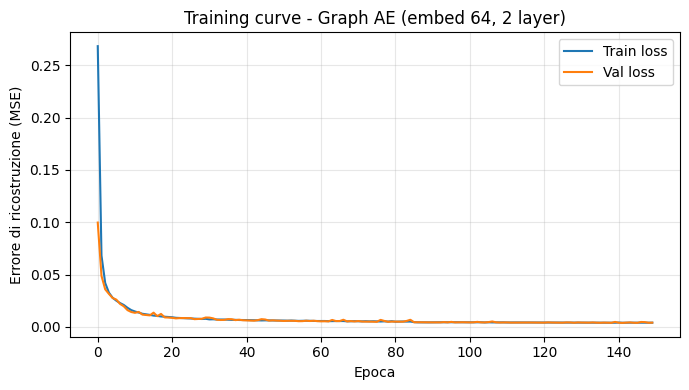

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(train_losses, label='Train loss')
ax.plot(val_losses,   label='Val loss')
ax.set_xlabel('Epoca'); ax.set_ylabel('Errore di ricostruzione (MSE)')
ax.set_title(f'Training curve - Graph AE (embed {EMBED_DIM}, {N_ENC} layer)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'gnn_training_curve.png'), dpi=130, bbox_inches='tight')
plt.show()


---
## 6. Anomaly score: errore di ricostruzione delle tracce

> **In breve.** Lo score di un jet è **quanto male** il modello (allenato sul QCD) ricostruisce
> le sue tracce, mediato su tutte le tracce del jet. I jet QCD si ricostruiscono bene (score
> basso), gli Emerging Jets peggio (score alto).

Perché la **media** sulle tracce e non, per esempio, la traccia ricostruita peggio? Perché su
questi dati gli EJ si distinguono dal QCD in modo **diffuso su molte tracce**, non per pochi
nodi isolati: la media cattura meglio questa differenza diffusa (concentrarsi sugli estremi
introduce solo rumore). È anche lo score più naturale per un autoencoder.

Qui tocchiamo per la prima volta test-QCD e segnale (mai visti in addestramento): nessun leakage.


In [7]:
def gnn_score(model, X, M, batch=512):
    '''Anomaly score per jet = errore medio di ricostruzione sulle sue tracce valide.'''
    model.eval(); out = []
    with torch.no_grad():
        for st in range(0, len(X), batch):
            xb = torch.from_numpy(X[st:st+batch]).to(DEVICE)
            mb = torch.from_numpy(M[st:st+batch]).to(DEVICE)
            out.append(masked_node_mse(model(xb, mb), xb, mb).cpu().numpy())
    return np.concatenate(out)

scores_bkg = gnn_score(model, Xte, Mte)
scores_sig = gnn_score(model, X_sig, M_sig)
print(f'QCD (test): {scores_bkg.mean():.4f} +/- {scores_bkg.std():.4f}')
print(f'EJ        : {scores_sig.mean():.4f} +/- {scores_sig.std():.4f}')
print(f'Delta (EJ - QCD): {scores_sig.mean() - scores_bkg.mean():+.4f}  (positivo = EJ piu anomalo)')


QCD (test): 0.0039 +/- 0.0028
EJ        : 0.0074 +/- 0.0047
Delta (EJ - QCD): +0.0035  (positivo = EJ piu anomalo)


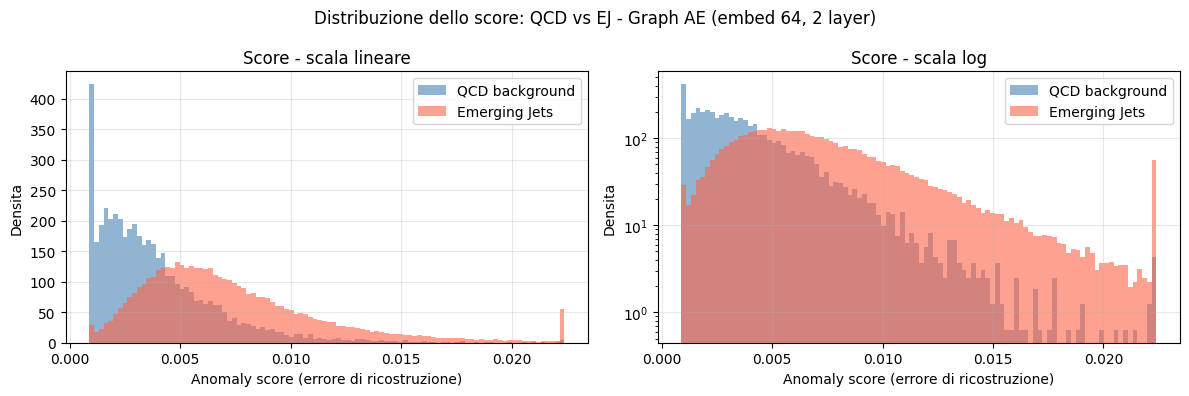

In [8]:
both = np.concatenate([scores_bkg, scores_sig])
lo, hi = np.percentile(both, 1), np.percentile(both, 99)
sb, ss = np.clip(scores_bkg, lo, hi), np.clip(scores_sig, lo, hi)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, logy in zip(axes, [False, True]):
    ax.hist(sb, bins=100, density=True, alpha=0.6, label='QCD background', color='steelblue')
    ax.hist(ss, bins=100, density=True, alpha=0.6, label='Emerging Jets',  color='tomato')
    ax.set_xlabel('Anomaly score (errore di ricostruzione)'); ax.set_ylabel('Densita')
    ax.set_title('Score - scala log' if logy else 'Score - scala lineare')
    if logy: ax.set_yscale('log')
    ax.legend(); ax.grid(alpha=0.3)
plt.suptitle(f'Distribuzione dello score: QCD vs EJ - Graph AE (embed {EMBED_DIM}, {N_ENC} layer)')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'gnn_score_distributions.png'), dpi=130, bbox_inches='tight')
plt.show()


---
## 7. Valutazione — ROC, AUC e SIC

> **In breve.** Misuriamo quanto bene lo score separa segnale e fondo con le metriche standard
> (ROC, AUC, SIC), le stesse degli altri modelli, così il confronto è diretto.


VALUTAZIONE FINALE (test-QCD + segnale, mai visti in addestramento)
  Config : embed 64, 2 layer attenzione, bottleneck 8
  AUC    : 0.7850
  N test-QCD: 7,500  |  N segnale: 50,000


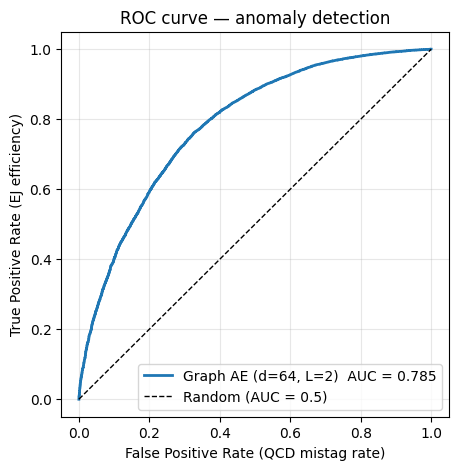

SIC massima : 1.339 @ eps_S = 0.71


In [9]:
fpr, tpr, roc_auc = compute_roc(scores_bkg, scores_sig)
print('=' * 55)
print('VALUTAZIONE FINALE (test-QCD + segnale, mai visti in addestramento)')
print('=' * 55)
print(f'  Config : embed {EMBED_DIM}, {N_ENC} layer attenzione, bottleneck {LATENT}')
print(f'  AUC    : {roc_auc:.4f}')
print(f'  N test-QCD: {len(scores_bkg):,}  |  N segnale: {len(scores_sig):,}')

plot_roc(fpr, tpr, roc_auc, label=f'Graph AE (d={EMBED_DIM}, L={N_ENC})',
         save_path=os.path.join(PLOTS_DIR, 'gnn_roc_finale.png'))
plt.show()

m   = fpr > 0
sic = tpr[m] / np.sqrt(fpr[m])
print(f'SIC massima : {sic.max():.3f} @ eps_S = {tpr[m][sic.argmax()]:.2f}')


---
## 8. Tuning degli iperparametri

> **In breve.** Cerchiamo le impostazioni migliori variando la **dimensione del collo di
> bottiglia** (la latent dimension), la **profondità** (quanti strati di attenzione) e la
> **regolarizzazione** (dropout). Il criterio è sempre l'errore di ricostruzione sui jet di
> **controllo** (QCD), mai il segnale.

Le tre manopole, mappate sulla consegna:
- **Latent dimension** (`latent`): la dimensione del collo di bottiglia. Più è grande, meglio
  l'autoencoder ricostruisce → errore di validation più basso, in modo monotòno → si sceglie il
  **gomito** (Occam): un bottleneck troppo largo lascerebbe «copiare» l'input e ricostruirebbe
  bene anche il segnale, peggiorando l'anomaly detection.
- **Capacità** (`n_enc`, numero di strati di attenzione): stesso ragionamento, si guarda il gomito.
- **Regolarizzazione** (`dropout`): non è capacità → si sceglie il valore con l'errore di
  validation **minimo**.

Nota sull'**input encoding**: qui *è* la rappresentazione ricca (le tracce come grafo) — è il
motivo stesso per cui usiamo una GNN. È l'alternativa all'aggregate usato dagli altri modelli.


In [6]:
def train_gnn_for_tuning(d, latent, n_enc, dropout, n_epochs=12, lr=1e-3, patience=4, device=DEVICE):
    '''Allena un graph AE (solo QCD) e restituisce la miglior val-loss di ricostruzione.
       20 epoche bastano per il confronto RELATIVO; il segnale non viene mai toccato.'''
    torch.manual_seed(SEED)
    m   = build_gnn(F, d, latent, n_enc, dropout).to(device)
    opt = torch.optim.Adam(m.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=2, factor=0.5)
    xv, mv = torch.from_numpy(Xvl).to(device), torch.from_numpy(Mvl).to(device)
    # tuning su un sottoinsieme ridotto: basta il confronto relativo tra le config
    N_TUNE = 10000
    tune_loader = DataLoader(TensorDataset(torch.from_numpy(Xtr[:N_TUNE]), torch.from_numpy(Mtr[:N_TUNE])),
                               batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
    best, wait = float('inf'), 0
    for _ in range(n_epochs):
        m.train()
        for xb, mb in tune_loader:
            xb, mb = xb.to(device), mb.to(device)
            loss = masked_node_mse(m(xb, mb), xb, mb).mean()
            opt.zero_grad(); loss.backward(); opt.step()
        m.eval()
        with torch.no_grad():
            val = masked_node_mse(m(xv, mv), xv, mv).mean().item()
        sched.step(val)
        if val < best - 1e-5:
            best, wait = val, 0
        else:
            wait += 1
            if wait >= patience: break
    return best


In [7]:
# ━━━ Esperimento 1 - Latent dimension (collo di bottiglia) ━━━━━━━━━━━━━━━━━━━
# Capacita' monotona -> scegli il GOMITO, non il minimo.
print('Esperimento 1: latent dim  (criterio: val-loss ricostruzione QCD)')
print(f"{'latent':>8} | {'val loss':>12}")
print('-' * 24)
latent_results = {}
for L in [4, 8, 16, 32]:
    latent_results[L] = train_gnn_for_tuning(EMBED_DIM, L, N_ENC, DROPOUT)
    print(f'{L:>8} | {latent_results[L]:>12.5f}')


Esperimento 1: latent dim  (criterio: val-loss ricostruzione QCD)
  latent |     val loss
------------------------
       4 |      0.15388
       8 |      0.03225
      16 |      0.00176
      32 |      0.00144


### Commento sui risultati dell'Esperimento 1 (latent dim)

| latent | val loss |
|--------|----------|
| 4      | 0.154    |
| 8      | 0.032    |
| 16     | 0.0018   |
| 32     | 0.0014   |

La val-loss **crolla** all'aumentare del bottleneck: a latent 16 l'autoencoder ricostruisce
quasi perfettamente (0.0018 ≈ zero). Sembrerebbe "il migliore"… ma per l'anomaly detection è una
**trappola**: un autoencoder che ricostruisce *tutto* alla perfezione ricostruisce bene **anche**
gli Emerging Jets → perde il potere di distinguerli → AUC peggiore. È esattamente il motivo per
cui scegliamo il **gomito**, non il minimo, e per cui un bottleneck stretto è meglio per l'AD.

Quindi **latent 8** (quello usato) è la scelta giusta: ricostruisce bene il QCD ma *non troppo*,
mantenendo la capacità di segnalare l'anomalo. È coerente con l'**AUC 0.7850** ottenuta.


In [8]:
# ━━━ Esperimento 2 - Profondità (numero di layer di attenzione) ━━━━━━━━━━━━━━
print('Esperimento 2: profondita  (criterio: val-loss ricostruzione QCD)')
print(f"{'n_enc':>8} | {'val loss':>12}")
print('-' * 24)
depth_results = {}
for ne in [1, 2, 3, 4]:
    depth_results[ne] = train_gnn_for_tuning(EMBED_DIM, LATENT, ne, DROPOUT)
    print(f'{ne:>8} | {depth_results[ne]:>12.5f}')


Esperimento 2: profondita  (criterio: val-loss ricostruzione QCD)
   n_enc |     val loss
------------------------
       1 |      0.03812
       2 |      0.03225
       3 |      0.03037
       4 |      0.03333


In [9]:
# ━━━ Esperimento 3 - Regolarizzazione (dropout) ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# La regolarizzazione non e' capacita': qui il criterio e' la val-loss MINIMA.
print('Esperimento 3: dropout  (criterio: val-loss ricostruzione QCD minima)')
print(f"{'dropout':>8} | {'val loss':>12}")
print('-' * 24)
drop_results = {}
for dp in [0.0, 0.1, 0.2]:
    drop_results[dp] = train_gnn_for_tuning(EMBED_DIM, LATENT, N_ENC, dp)
    print(f'{dp:>8.1f} | {drop_results[dp]:>12.5f}')
best_drop = min(drop_results, key=drop_results.get)
print(f'\nMiglior dropout (val-loss minima): {best_drop}')


Esperimento 3: dropout  (criterio: val-loss ricostruzione QCD minima)
 dropout |     val loss
------------------------
     0.0 |      0.03225
     0.1 |      0.03896
     0.2 |      0.04597

Miglior dropout (val-loss minima): 0.0


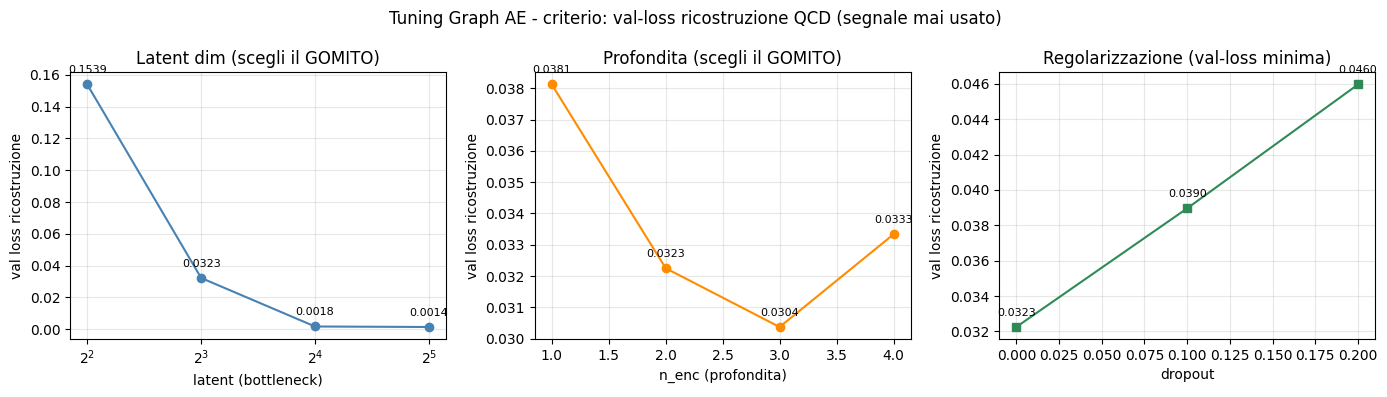

In [10]:
# ── Riepilogo del tuning: una curva per ciascuna manopola ────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

ax = axes[0]
ks, vs = list(latent_results), list(latent_results.values())
ax.plot(ks, vs, 'o-', color='steelblue'); ax.set_xscale('log', base=2)
ax.set_xlabel('latent (bottleneck)'); ax.set_ylabel('val loss ricostruzione')
ax.set_title('Latent dim (scegli il GOMITO)'); ax.grid(alpha=0.3)
for k, v in zip(ks, vs):
    ax.annotate(f'{v:.4f}', (k, v), textcoords='offset points', xytext=(0, 8), ha='center', fontsize=8)

ax = axes[1]
ks, vs = list(depth_results), list(depth_results.values())
ax.plot(ks, vs, 'o-', color='darkorange')
ax.set_xlabel('n_enc (profondita)'); ax.set_ylabel('val loss ricostruzione')
ax.set_title('Profondita (scegli il GOMITO)'); ax.grid(alpha=0.3)
for k, v in zip(ks, vs):
    ax.annotate(f'{v:.4f}', (k, v), textcoords='offset points', xytext=(0, 8), ha='center', fontsize=8)

ax = axes[2]
ks, vs = list(drop_results), list(drop_results.values())
ax.plot(ks, vs, 's-', color='seagreen')
ax.set_xlabel('dropout'); ax.set_ylabel('val loss ricostruzione')
ax.set_title('Regolarizzazione (val-loss minima)'); ax.grid(alpha=0.3)
for k, v in zip(ks, vs):
    ax.annotate(f'{v:.4f}', (k, v), textcoords='offset points', xytext=(0, 8), ha='center', fontsize=8)

plt.suptitle('Tuning Graph AE - criterio: val-loss ricostruzione QCD (segnale mai usato)')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'gnn_tuning_summary.png'), dpi=130, bbox_inches='tight')
plt.show()


## Scelta di design: whitening testato, non adottato

Abbiamo testato lo score **whitened** (errore per-feature normalizzato per la varianza di ricostruzione sul QCD), che migliora i modelli nello spazio *aggregate* (AE, VAE, diffusion). A livello di **traccia**, pero', **peggiora**: misurato sull'EdgeConv, AUC 0.699 -> 0.687. Il motivo: feature con errore di ricostruzione QCD piccolissimo (es. `numberOfInnermostPixelLayerHits`, ~0.001) vengono amplificate ~25x e sbilanciano lo score. Quindi qui **manteniamo lo score MSE a peso uguale** (baseline) - scelta supportata dalla misura.

## Export per la Task 3 - salvataggio degli anomaly-score

Salva lo score **ufficiale** del modello (lo *whitened* dove adottato, altrimenti il baseline) e, per sicurezza, anche il **baseline** (`scores_*_base`), piu' gli indici `idx_sig`/`idx_bkg` per agganciare decay length e massa. Ricaricati dal notebook `08` per il confronto, senza riallenare.

In [10]:
# === TASK3 EXPORT ===
# Salva gli anomaly-score (ufficiale + baseline) per il confronto in 08_evaluation_task3_locale.
import os, numpy as np
TASK3_DIR = "C:/Users/dfraj/OneDrive/Desktop/Master/Adv_ML/Progetto/ej_anomaly/notebooks_locali/task3_scores"
os.makedirs(TASK3_DIR, exist_ok=True)
# score ufficiale del modello (whitened se definito, altrimenti baseline del notebook)
sb = (scores_bkg_official if 'scores_bkg_official' in dir() else
      scores_bkg_test if 'scores_bkg_test' in dir() else scores_bkg)
ss = (scores_sig_official if 'scores_sig_official' in dir() else
      scores_sig_final if 'scores_sig_final' in dir() else scores_sig)
sb = np.asarray(sb, np.float32); ss = np.asarray(ss, np.float32)
idx_sig = np.arange(len(ss), dtype=np.int32)
_it = idx_test if 'idx_test' in dir() else (ite if 'ite' in dir() else None)
idx_bkg = np.asarray(_it, np.int32) if _it is not None else np.arange(len(sb), np.int32)
assert len(idx_bkg) == len(sb)
extra = {}
if 'scores_bkg_base' in dir() and 'scores_sig_base' in dir():
    extra['scores_bkg_base'] = np.asarray(scores_bkg_base, np.float32)
    extra['scores_sig_base'] = np.asarray(scores_sig_base, np.float32)
_path = os.path.join(TASK3_DIR, "gnn_transformer.npz")
np.savez_compressed(_path, scores_bkg=sb, scores_sig=ss, idx_sig=idx_sig, idx_bkg=idx_bkg,
                    model_name="GNN attenzione (Transformer)", **extra)
print(f"[Task 3] Salvato {_path} | bkg {len(sb):,} | sig {len(ss):,}" + (" (+baseline)" if extra else ""))
try:
    from sklearn.metrics import roc_auc_score
    y = np.r_[np.zeros(len(sb)), np.ones(len(ss))]
    print(f"         AUC ufficiale: {roc_auc_score(y, np.r_[sb, ss]):.4f}")
except Exception as e:
    print("         (AUC quick-check non disponibile)", e)

[Task 3] Salvato C:/Users/dfraj/OneDrive/Desktop/Master/Adv_ML/Progetto/ej_anomaly/notebooks_locali/task3_scores\gnn_transformer.npz | bkg 7,500 | sig 50,000
         AUC ufficiale: 0.7850
